## Sentiment Analysis of a Gaming Community with Strong Ties to its Developer



### Introduction

2007scape is the main subreddit for fans of Old School Runescape (OSRS), a 2007 version of the online game Runescape made by the same developers, Jagex, after a series of controversial updates to the main game that ignored player feedback. OSRS has surpassed the main game to be the second largest Massive Multiplayer Online Role Playing Game (MMORPG) today. The base idea of OSRS is that players drive the direction of the game hand in hand with the developer. As a result, Jagex employees often will directly reply to players on the subreddit as a show of transparency. A gaming community that is used to a developer actively listening to it is a unique network to analyze.

Data was collected 100 records at a time from Reddit and saved at: https://github.com/Megabuster/DATA620/tree/main/final_project. This particular snapshot of the data was from May 2, 2026. Jagex employees had very few responses at this time since the game was in a bit of a downtime. Updates typically are midweek and this was the start of the weekend. Additionally,  there was a two month event known as Leagues in progress meaning that updates were on hold to make sure the event ran smoothly. Notably, the main discussions with Jagex employees regarding the state of the even would have happened before and during the earlier days of the event. By this point, Jagex had already announced that development focus was now on upcoming updates for the summer. While we can still expect posts to be seen by Jagex employees, their lack of presence should have allowed for more organic discussions to happen that day.



### Abstract

The main focus of this analysis is on sentiments. Threads and comments can exhibit positive, neutral, or negative sentiments depending on what the user intends to convey. These sentiments may have trends based on the topic such as complaints or recognition toward Jagex as a whole. There was a void of Jagex employees, also known as J-Mods, in this snapshot. "Superstar" users emerged in their stead. Even when driven by "superstar" users with high activity and engagement, sentiments were usually positive or neutral. Topics included "Discussions", "Humor", and "Leagues" (the name of the temporary event), suggesting diverse interactions on both the lighthearted and series aspects of the game. Overall, the community trends positive despite common beliefs about gaming community toxicity.

In [1]:
# imports
import re
import string
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('vader_lexicon', quiet=True)

stop_words = set(stopwords.words('english'))

### EDA and Data Preparation

In [2]:
import pandas as pd

# Load the datasets into pandas DataFrames directly from URL
threads_url = 'https://raw.githubusercontent.com/Megabuster/DATA620/main/final_project/posts_with_comments.json'
comments_url = 'https://raw.githubusercontent.com/Megabuster/DATA620/main/final_project/comments_with_post_titles.json'

threads_df = pd.read_json(threads_url)
comments_df = pd.read_json(comments_url)

The datasets are split into two groups: comments and threads.

* `Threads` are message board posts by a user that can be interacted with.
* `Comments` are replies in a thread. They can also be replies to other comments. We will generally focus on connections between comments and threads.

#### Handling Missing Values

Before analyzing the datasets further, we will check if there are any columns with lacking data.

In [3]:
# Function to drop columns with more than 90% missing values
def drop_sparse_columns(df, threshold=0.9):
    nan_counts = df.isnull().sum()
    nan_percentages = nan_counts / len(df)
    columns_to_drop = nan_percentages[nan_percentages > threshold].index.tolist()
    return df.drop(columns=columns_to_drop)

# Apply to comments_df
original_comments_cols = comments_df.shape[1]
comments_df = drop_sparse_columns(comments_df, threshold=0.9)
print(f'Comments DataFrame: Reduced from {original_comments_cols} to {comments_df.shape[1]} columns.')

# Apply to threads_df
original_threads_cols = threads_df.shape[1]
threads_df = drop_sparse_columns(threads_df, threshold=0.9)
print(f'Threads DataFrame: Reduced from {original_threads_cols} to {threads_df.shape[1]} columns.')

Comments DataFrame: Reduced from 222 to 58 columns.
Threads DataFrame: Reduced from 2394 to 85 columns.


There are no columns with over 90% missing values.

#### Data Examination and Type Conversion

In [4]:
print('Comments DataFrame columns and dtypes after sparse column removal:')
print(comments_df.info())

print('\nThreads DataFrame columns and dtypes after sparse column removal:')
print(threads_df.info())

Comments DataFrame columns and dtypes after sparse column removal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 58 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   kind                           804 non-null    object
 1   subreddit_id                   804 non-null    object
 2   author_is_blocked              804 non-null    bool  
 3   link_title                     804 non-null    object
 4   ups                            804 non-null    int64 
 5   author_flair_type              804 non-null    object
 6   total_awards_received          804 non-null    int64 
 7   subreddit                      804 non-null    object
 8   link_author                    804 non-null    object
 9   replies                        804 non-null    object
 10  user_reports                   804 non-null    object
 11  saved                          804 non-null    bool  
 1

We're interested in analyzing threads (posts) and comments and their connections. Key columns for this include:
- **Text content**: `body` (comments), `selftext`, `title` (threads)
- **Author information**: `author`, `author_fullname`
- **Engagement metrics**: `ups`, `score`, `num_comments` (threads)
- **Relationships**: `parent_id` (comments), `link_id` (comments relating to threads)

Text content can be used for sentiment analysis. Author information allows us to check which users have strong centralities.

Engagement metrics are useful for weighing a comment's popularity. The values `ups` and `downs` are meant to indicate how many upvotes and downvotes that post or comment has received. This is a form of sentiment labeling which Reddit's algorithm uses to determine which posts or comments should be promoted. While this may be true internally, in our data, things work a bit differently.

In [5]:
print("Verifying relationship between 'score', 'ups', and 'downs' in comments_df:")
# Calculate score from ups and downs if downs were non-zero
# Since 'downs' is always 0, ideally 'score' should equal 'ups'
display(comments_df[['score', 'ups', 'downs']].head())

# Check if score always equals ups when downs is 0
is_score_equal_ups = (comments_df['score'] == comments_df['ups']).all()
print(f"Is 'score' always equal to 'ups' when 'downs' is 0 in comments_df? {is_score_equal_ups}")

# If not, let's see where they differ
if not is_score_equal_ups:
    print("Rows where 'score' != 'ups' in comments_df (should not happen if 'downs' is always 0):")
    display(comments_df[comments_df['score'] != comments_df['ups']][['score', 'ups', 'downs']].head())

print("\nVerifying relationship between 'score', 'ups', and 'downs' in threads_df:")
display(threads_df[['score', 'ups', 'downs']].head())
is_score_equal_ups_threads = (threads_df['score'] == threads_df['ups']).all()
print(f"Is 'score' always equal to 'ups' when 'downs' is 0 in threads_df? {is_score_equal_ups_threads}")


Verifying relationship between 'score', 'ups', and 'downs' in comments_df:


,score,ups,downs
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0


Is 'score' always equal to 'ups' when 'downs' is 0 in comments_df? True

Verifying relationship between 'score', 'ups', and 'downs' in threads_df:


,score,ups,downs
0,5,5,0
1,1824,1824,0
2,1549,1549,0
3,307,307,0
4,444,444,0


Is 'score' always equal to 'ups' when 'downs' is 0 in threads_df? True


`Ups` is just another form of `score` and `downs` appears to be unused. Social media and comparable online news aggregators have been trending towards leaving upvotes visible, but hiding downvotes. The goal is to somewhat control sentiments and hopefully encourage people to read the post before making an opinion. It is easy for negative sentiments to snowball.

In [6]:
relevant_threads_cols = [
    'id', 'created_utc', 'author', 'author_fullname', 'title', 'selftext',
    'score', 'ups', 'num_comments', 'total_awards_received'
]

relevant_comments_cols = [
    'id', 'parent_id', 'link_id', 'created_utc', 'author', 'author_fullname',
    'body', 'score', 'ups', 'total_awards_received', 'link_title'
]

print("\nMissing values in threads_df")
display(threads_df[relevant_threads_cols].isnull().sum())

print("\nMissing values in comments_df:")
display(comments_df[relevant_comments_cols].isnull().sum())




Missing values in threads_df


,0
id,0
created_utc,0
author,0
author_fullname,0
title,0
selftext,0
score,0
ups,0
num_comments,0
total_awards_received,0



Missing values in comments_df:


,0
id,0
parent_id,0
link_id,0
created_utc,0
author,0
author_fullname,0
body,0
score,0
ups,0
total_awards_received,0


Once again, no critical data seems to be missing.

#### Data Type Conversion and ID Cleaning

In [7]:
# Convert 'created_utc' to datetime for both DataFrames
comments_df['created_utc'] = pd.to_datetime(comments_df['created_utc'], unit='s')
threads_df['created_utc'] = pd.to_datetime(threads_df['created_utc'], unit='s')

# Clean 'link_id' in comments_df by removing 't3_'
# 'link_id' in comments refers to the thread it belongs to, which corresponds to 'id' in threads_df
comments_df['link_id'] = comments_df['link_id'].str.replace('t3_', '')

# 'parent_id' in comments_df can refer to either a comment ('t1_') or a thread ('t3_')
# We'll clean both prefixes for consistency, useful for hierarchical comment analysis
comments_df['parent_id'] = comments_df['parent_id'].str.replace('t1_', '').str.replace('t3_', '')

DateTime is standard for Python time handling with available functions. Streamlining `link_id` and `parent_id` helps with connecting threads and comments later.

In [8]:
print('Unique values in link_flair_text column (threads_df):')
display(threads_df['link_flair_text'].unique())

Unique values in link_flair_text column (threads_df):


array([None, 'Humor', 'RNG', ':leagues-badge: Leagues', 'Achievement',
       'Discussion', 'Creative', 'Suggestion', 'Other', 'Question',
       'Discussion | J-Mod reply', 'Video'], dtype=object)

These tags are meant to show the main purpose of a thread. Threads can change in scope through more replies. For example, a thread tagged with "J-Mod reply" could be any topic, but has a special note that a Jagex employee engaged with it. Jagex interactions are especially interesting because they represent an extension of the company making the game that everyone is discussing.

In [9]:
jmod_threads = threads_df[threads_df['link_flair_text'].str.contains('J-Mod reply', na=False)]
display(jmod_threads.head())

jagex_authors_comments = comments_df[comments_df['author'].str.contains('Jagex', na=False, case=False) | comments_df['author_fullname'].str.contains('Jagex', na=False, case=False)]
jagex_authors_threads = threads_df[threads_df['author'].str.contains('Jagex', na=False, case=False) | threads_df['author_fullname'].str.contains('Jagex', na=False, case=False)]

print('Comments by authors with "Jagex" in their name:')
if not jagex_authors_comments.empty:
    display(jagex_authors_comments[['author', 'author_fullname', 'body']].head())
else:
    print('No comments found by authors containing "Jagex" in their name.')

print('\nThreads by authors with "Jagex" in their name:')
if not jagex_authors_threads.empty:
    display(jagex_authors_threads[['author', 'author_fullname', 'title', 'selftext']].head())
else:
    print('No threads found by authors containing "Jagex" in their name.')

,kind,subreddit,selftext,author_fullname,saved,gilded,clicked,title,link_flair_richtext,subreddit_name_prefixed,...,url,subreddit_subscribers,created_utc,num_crossposts,is_video,url_overridden_by_dest,link_flair_template_id,post_hint,preview.images,preview.enabled
55,t3,2007scape,,t2_234j3e9gri,False,0,False,I miss when forestry was a massively multiplay...,"[{'e': 'text', 't': 'Discussion | J-Mod reply'}]",r/2007scape,...,https://i.redd.it/yk5ww4r69hyg1.png,1336598,2026-05-01 07:22:44,0,False,https://i.redd.it/yk5ww4r69hyg1.png,None,image,[{'source': {'url': 'https://preview.redd.it/y...,1.0


Comments by authors with "Jagex" in their name:
No comments found by authors containing "Jagex" in their name.

Threads by authors with "Jagex" in their name:
No threads found by authors containing "Jagex" in their name.


Unfortunately, only one thread was found with Jagex employee responses. The actual response could not be found. The limitation of Reddit's available posts and comments is a hard number of the most recent 1000 of both categories. This means that the thread was still among the 1000 most common posts, but the comment was not.

## Data Analysis

We have a few main steps for our full analysis.
* Discover the sentiments within the texts of user comments and posts.
* Were there any "superstar" users? Who were they?
* Use centrality measures to expose trends in threads and comments.


### Text Preprocessing and Sentiment Analysis

To analyze the main topics and sentiments within the Reddit data, we first need to preprocess the text content from both threads and comments. This involves combining relevant text fields, cleaning the text, and then tokenizing and removing stopwords.

In [10]:
# Combine title and selftext for threads_df
threads_df['full_text'] = threads_df['title'].fillna('') + ' ' + threads_df['selftext'].fillna('')

# Rename body to full_text for comments_df for consistency
comments_df['full_text'] = comments_df['body'].fillna('')

def clean_text(text):
    text = text.lower() # Lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    # text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.strip() # Remove leading/trailing whitespace
    return text

threads_df['cleaned_text'] = threads_df['full_text'].apply(clean_text)
comments_df['cleaned_text'] = comments_df['full_text'].apply(clean_text)

print(f'Example thread text: {threads_df['cleaned_text'].iloc[0][:200]}')
print(f'\nExample comment text: {comments_df['cleaned_text'].iloc[0][:200]}')

Example thread text: have a question about the game or the subreddit ask away  welcome to the daily r2007scape question thread

you can ask anything about old school runescape here they are designated for you to ask anyth

Example comment text: how do you get 48 dps from kings barrage my build only gets me 31 dps max


The chosen thread seems to be a "megathread" which is usually designed as a catch all so that certain questions don't flood the subreddit. We will keep this in mind for later if it leads to a high amount of clustering.

The chosen comment is a simple question regarding builds and is a good example of neutral sentiment or a positive engagement post.

We cleaned the text by converting it to lowercase and removing punctuation. We kept numbers because there is potential for meaning behind what numbers people use.

### TF-IDF Vectorization for Topic Modeling

We will convert the processed text into a numerical format using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization. This technique assigns weights to words based on their frequency in a document and their rarity across all documents, highlighting words that are significant to a specific document. We will also tokenize the words and remove stopwords which tend to provide little meaning and instead introduce noise.

In [11]:
def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

threads_df['processed_text'] = threads_df['cleaned_text'].apply(tokenize_and_remove_stopwords)
comments_df['processed_text'] = comments_df['cleaned_text'].apply(tokenize_and_remove_stopwords)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer_threads = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')
tfidf_vectorizer_comments = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')

# Fit and transform the processed text for threads
tfidf_matrix_threads = tfidf_vectorizer_threads.fit_transform(threads_df['processed_text'])

# Fit and transform the processed text for comments
tfidf_matrix_comments = tfidf_vectorizer_comments.fit_transform(comments_df['processed_text'])

print('TF-IDF matrices created for threads and comments.')
print(f'Shape of TF-IDF matrix for threads: {tfidf_matrix_threads.shape}')
print(f'Shape of TF-IDF matrix for comments: {tfidf_matrix_comments.shape}')

# Get feature names (words) for later interpretation
feature_names_threads = tfidf_vectorizer_threads.get_feature_names_out()
feature_names_comments = tfidf_vectorizer_comments.get_feature_names_out()

stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

threads_df['processed_text'] = threads_df['cleaned_text'].apply(tokenize_and_remove_stopwords)
comments_df['processed_text'] = comments_df['cleaned_text'].apply(tokenize_and_remove_stopwords)

TF-IDF matrices created for threads and comments.
Shape of TF-IDF matrix for threads: (114, 525)
Shape of TF-IDF matrix for comments: (804, 1000)


### Visualize TF-IDF Feature Importance for Comments

To understand which terms are most important across all comments, we can visualize the TF-IDF feature importance. We'll sum the TF-IDF scores for each term and display the top terms.

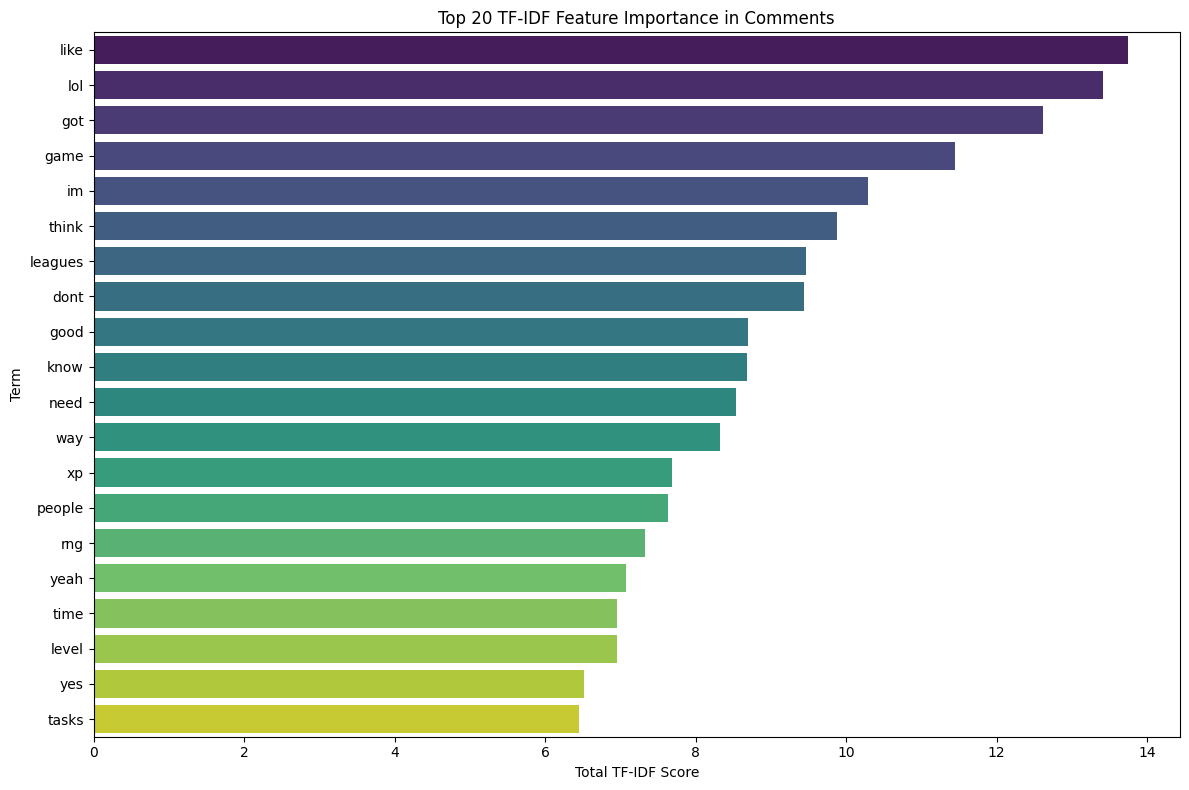

In [12]:
# Calculate the sum of TF-IDF scores for each term in comments_df
feature_scores_comments = np.sum(tfidf_matrix_comments, axis=0)

# Convert to a dense array and then flatten for easier manipulation
feature_scores_comments = np.asarray(feature_scores_comments).flatten()

# Create a series for easier sorting and selection
feature_importance_comments = pd.Series(feature_scores_comments, index=feature_names_comments)

# Get the top N most important terms
top_n_terms = 20
top_terms_comments = feature_importance_comments.nlargest(top_n_terms)

# Create the visualization
plt.figure(figsize=(12, 8))
sns.barplot(x=top_terms_comments.values, y=top_terms_comments.index, palette='viridis', hue=top_terms_comments.index, legend=False)
plt.title(f'Top {top_n_terms} TF-IDF Feature Importance in Comments')
plt.xlabel('Total TF-IDF Score')
plt.ylabel('Term')
plt.tight_layout()
plt.show()

The top TF-IDF scoring words show a few trends. Like apparently was not filtered out as a stop word, but it is a relatively low meaning word in most instances. In conversational text, it may have even less meaning as a verbal inflection rather than a signal of a simile. The words here do not seem to have too much meaning aside from a select few such as "leagues" which is the term for the current seasonal event  and "xp" which is short for experience (points). Experience is the term for points used to level up different skills to make your character stronger.

### Sentiment Analysis using VADER

We will now perform sentiment analysis on the `processed_text` of both threads and comments using VADER (Valence Aware Dictionary and sEntiment Reasoner). VADER is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media.

Start by setting up VADER.

In [13]:
# Initialize the VADER sentiment intensity analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment_scores(text):
    if not isinstance(text, str): # Handle non-string types
        return {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}
    return sia.polarity_scores(text)

# Apply sentiment analysis to threads_df
threads_df['sentiment'] = threads_df['processed_text'].apply(get_sentiment_scores)
threads_df['compound_sentiment'] = threads_df['sentiment'].apply(lambda x: x['compound'])

# Apply sentiment analysis to comments_df
comments_df['sentiment'] = comments_df['processed_text'].apply(get_sentiment_scores)
comments_df['compound_sentiment'] = comments_df['sentiment'].apply(lambda x: x['compound'])

print("Sentiment analysis complete for threads and comments.")

Sentiment analysis complete for threads and comments.


Now that we have the compound sentiment scores, let's categorize them into 'Positive', 'Negative', and 'Neutral' for easier interpretation and visualization.

We'll use common thresholds:
*   Compound score >= 0.05: Positive
*   Compound score <= -0.05: Negative
*   Between -0.05 and 0.05: Neutral

In [14]:
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

threads_df['sentiment_label'] = threads_df['compound_sentiment'].apply(categorize_sentiment)
comments_df['sentiment_label'] = comments_df['compound_sentiment'].apply(categorize_sentiment)

print("Sentiment labels added to threads and comments.")

Sentiment labels added to threads and comments.


Let's visualize the distribution of sentiment labels for both threads and comments to get an overview of the general sentiment.

/tmp/ipykernel_6907/45571162.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=threads_df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
/tmp/ipykernel_6907/45571162.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=comments_df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])


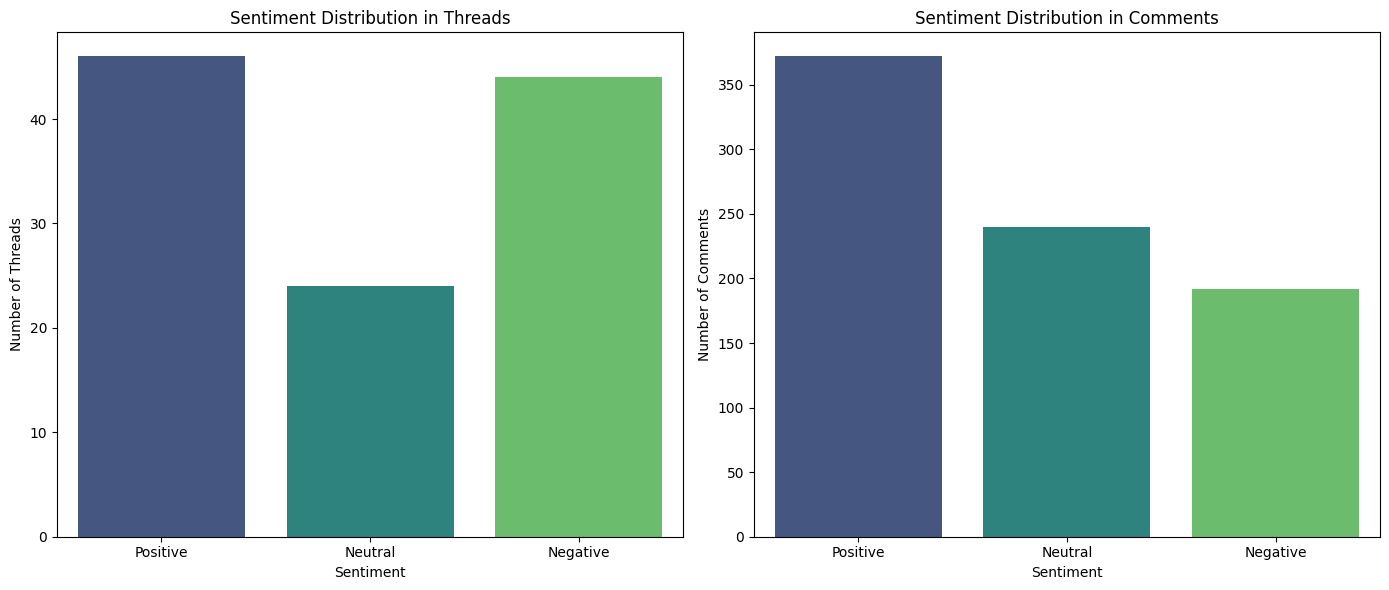

In [15]:
plt.figure(figsize=(14, 6))

# Plot sentiment distribution for Threads
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.countplot(x='sentiment_label', data=threads_df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution in Threads')
plt.xlabel('Sentiment')
plt.ylabel('Number of Threads')

# Plot sentiment distribution for Comments
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.countplot(x='sentiment_label', data=comments_df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution in Comments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')

plt.tight_layout()
plt.show()

While the correlations between threads and comments are a bit broken because of the 1000 records limitation, what we have here still represents nearly 1000 of our most recent comments and the threads they were a part of.

Positive sentiments were most common in both datasets. However, negative threads were extremely common still with neutral threads being uncommon. This could be because there is not much of a reason to post a new thread unless a user wanted to evoke positive or negative emotions.

Comments had a more linear dropoff in sentiment from positive to negative. This would imply that many of these positive comments occurred in negative threads. A potential reason is that someone entering into a negative comment likely agrees with the thread topic already, similar to how a commenter in a positive thread likely shares that sentiment. Within the scope of what VADER is examining, echoing a negative sentiment would technically appear positive.  

In [16]:
print("Example threads with sentiments:")
display(threads_df[['processed_text', 'compound_sentiment', 'sentiment_label']].head())

print("\nExample comments with sentiments:")
display(comments_df[['processed_text', 'compound_sentiment', 'sentiment_label']].head())

Example threads with sentiments:


,processed_text,compound_sentiment,sentiment_label
0,question game subreddit ask away welcome daily...,0.7964,Positive
1,worst misclick life,-0.6249,Negative
2,pretty good start moons grind,0.7269,Positive
3,mimegate falls top 10 surely next league chang...,0.5719,Positive
4,took 27 cigarettes bird juice drink calm,0.3182,Positive



Example comments with sentiments:


,processed_text,compound_sentiment,sentiment_label
0,get 48 dps kings barrage build gets 31 dps max,0.0000,Neutral
1,took wildy partly kill people,-0.6605,Negative
2,true bring rope,0.4215,Positive
3,lol removing random event related tasks gameal...,0.1779,Positive
4,leagues got mutagens way blowpipe dont think t...,-0.7187,Negative


Understanding the example sentiments requires a bit of domain knowledge. Sentiment scores favor messages with positive words in them regardless of exact context such as "question game subreddit ask away welcome daily" or "pretty good start moons grind". The former was identified as a generic "megathread" to reduce low quality thread spam. In a sense it could be seen as positive since it does promote a positive effect, but it probably makes more sense being neutral. There will only ever be one pinned thread like this at a time, so it does not represent a problem with the categorization process. The latter was a good example of a very strongly positive sentiment. The user appears to be bragging about good luck obtain good items from "moons".

For negative classified sentiments, examples include "worst misclick life" and "leagues got mutagens way blowpipe dont think". The former message is lamenting a mistake. The latter is a bit hard to gauge from this snippet.

In [17]:
comment_text_filter = 'leagues got mutagens way blowpipe dont think'
filtered_comment = comments_df[comments_df['processed_text'].str.contains(comment_text_filter, na=False)]
display(filtered_comment['processed_text'].iloc[0])

'leagues got mutagens way blowpipe dont think theyre boosted drop rates really sucks temp game mode'

With a litle more context, it does appear to be negative, although the meaning of this message is still a mystery. The user is unhappy about a situation.

### Identifying 'Superstar' Users

Now that we have classified our threads and comments as positive, neutral, and negative, let's move the focus to the people expressing those sentiments: the users. To identify 'superstar' users, we will consider two main criteria: activity and engagement. Activity will be measured by the total number of posts (threads) and comments made, while engagement will be measured by the sum of `score` (upvotes) received across all their contributions.

We will aggregate user data from both `threads_df` and `comments_df` as users are the authors of both threads and comments.

In [18]:
# Aggregate user activity from threads
thread_authors_activity = threads_df.groupby('author').agg(
    thread_count=('id', 'size'),
    total_thread_score=('score', 'sum'),
    avg_thread_sentiment=('compound_sentiment', 'mean')
).reset_index()

# Aggregate user activity from comments
comment_authors_activity = comments_df.groupby('author').agg(
    comment_count=('id', 'size'),
    total_comment_score=('score', 'sum'),
    avg_comment_sentiment=('compound_sentiment', 'mean')
).reset_index()

# Merge the two activity dataframes
user_activity = pd.merge(
    thread_authors_activity,
    comment_authors_activity,
    on='author',
    how='outer'
).fillna(0)

# Calculate total activity and engagement
user_activity['total_posts_comments'] = user_activity['thread_count'] + user_activity['comment_count']
user_activity['total_score'] = user_activity['total_thread_score'] + user_activity['total_comment_score']
user_activity['overall_avg_sentiment'] = (
    (user_activity['avg_thread_sentiment'] * user_activity['thread_count']) +
    (user_activity['avg_comment_sentiment'] * user_activity['comment_count']) # Weighted average
) / user_activity['total_posts_comments']

# Handle cases where total_posts_comments might be 0 (e.g., if a user only exists in one df but had 0 count)
user_activity['overall_avg_sentiment'] = user_activity['overall_avg_sentiment'].fillna(0)

print("User activity and engagement aggregated.")
display(user_activity.sort_values(by='total_posts_comments', ascending=False).head())

User activity and engagement aggregated.


,author,thread_count,total_thread_score,avg_thread_sentiment,comment_count,total_comment_score,avg_comment_sentiment,total_posts_comments,total_score,overall_avg_sentiment
92,Competitive-Math1153,1.0,0.0,-0.5951,12.0,12.0,0.124567,13.0,12.0,0.069208
604,megareader,1.0,50.0,-0.4215,7.0,9.0,0.292329,8.0,59.0,0.203100
500,barcode-lz,0.0,0.0,0.0000,7.0,8.0,-0.195971,7.0,8.0,-0.195971
455,VDred,1.0,28.0,0.8126,6.0,89.0,0.207000,7.0,117.0,0.293514
481,Zibbi-Akbar,0.0,0.0,0.0000,6.0,1.0,0.190067,6.0,1.0,0.190067


Now, let's define and identify the 'superstar' users. We can set thresholds for total posts/comments and total score to find the most active and impactful users. For example, we could define superstars as users in the top 10% for both total posts/comments and total score.

In [19]:
# Define superstar criteria (e.g., top 10% in both categories)
posts_comments_threshold = user_activity['total_posts_comments'].quantile(0.90)
score_threshold = user_activity['total_score'].quantile(0.90)

superstar_users = user_activity[
    (user_activity['total_posts_comments'] >= posts_comments_threshold) &
    (user_activity['total_score'] >= score_threshold)
].sort_values(by='total_score', ascending=False)

print(f"Identified {len(superstar_users)} superstar users based on top 10% activity and score.")
display(superstar_users)

Identified 19 superstar users based on top 10% activity and score.


,author,thread_count,total_thread_score,avg_thread_sentiment,comment_count,total_comment_score,avg_comment_sentiment,total_posts_comments,total_score,overall_avg_sentiment
63,Business_Match_9349,1.0,2247.0,-0.88600,2.0,3.0,0.356800,3.0,2250.0,-0.057467
311,NoPollution5410,2.0,1602.0,-0.35855,0.0,0.0,0.000000,2.0,1602.0,-0.358550
233,Kangarooman64,1.0,910.0,0.22630,2.0,2.0,0.000000,3.0,912.0,0.075433
435,The_Level_15,1.0,799.0,0.00000,3.0,11.0,-0.487100,4.0,810.0,-0.365325
628,old-skool-bro,1.0,444.0,0.31820,4.0,10.0,0.175300,5.0,454.0,0.203880
269,MCharon,1.0,398.0,0.99660,3.0,3.0,0.140500,4.0,401.0,0.354525
230,JustLivingSimply,1.0,284.0,0.98590,4.0,4.0,0.114700,5.0,288.0,0.288940
116,DiabloPhD,1.0,226.0,0.94210,1.0,1.0,-0.296000,2.0,227.0,0.323050
117,DidUSayWeast,1.0,216.0,0.52000,2.0,2.0,0.000000,3.0,218.0,0.173333
468,WeirdFedoraGuy,1.0,152.0,0.99620,4.0,4.0,0.256700,5.0,156.0,0.404600


Let's analyze the sentiment distribution of these 'superstar' users compared to the general user base.

/tmp/ipykernel_6907/1029363308.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=superstar_sentiment, palette='viridis', order=['Positive', 'Neutral', 'Negative'])


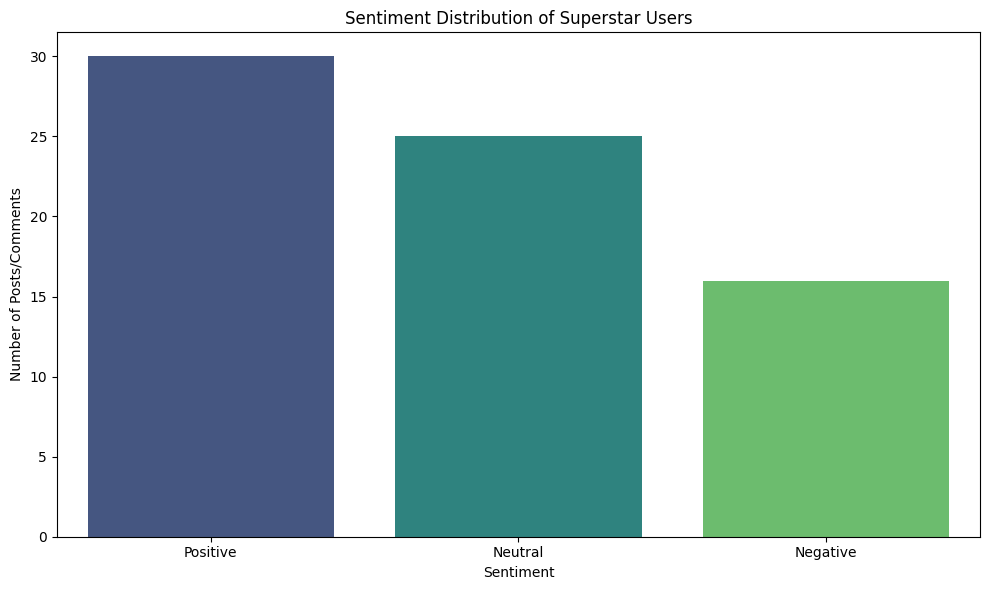

,proportion
sentiment_label,
Positive,0.422535
Neutral,0.352113
Negative,0.225352


In [20]:
# Merge sentiment labels for superstar users
superstar_authors_list = superstar_users['author'].tolist()

# Get sentiment labels for superstar threads
superstar_threads_sentiment = threads_df[threads_df['author'].isin(superstar_authors_list)]['sentiment_label']

# Get sentiment labels for superstar comments
superstar_comments_sentiment = comments_df[comments_df['author'].isin(superstar_authors_list)]['sentiment_label']

# Combine and visualize sentiment for superstar users
superstar_sentiment = pd.concat([superstar_threads_sentiment, superstar_comments_sentiment])

plt.figure(figsize=(10, 6))
sns.countplot(x=superstar_sentiment, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution of Superstar Users')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts/Comments')
plt.tight_layout()
plt.show()

display(superstar_sentiment.value_counts(normalize=True))

This distribution of superstar users looks similar to that of comments. This makes sense because comments outnumber threads in a many-to-one ratio.

### Correlation of Sentiment with Engagement

Now, let's investigate if there's a relationship between the sentiment of posts/comments and their engagement metrics, such as `score` and `num_comments`. We'll focus on threads first, as they have direct `num_comments` and a clear `score`.

/tmp/ipykernel_6907/219922097.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_label', y='score', data=threads_df, order=['Positive', 'Neutral', 'Negative'], palette='coolwarm')
/tmp/ipykernel_6907/219922097.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_label', y='num_comments', data=threads_df, order=['Positive', 'Neutral', 'Negative'], palette='coolwarm')


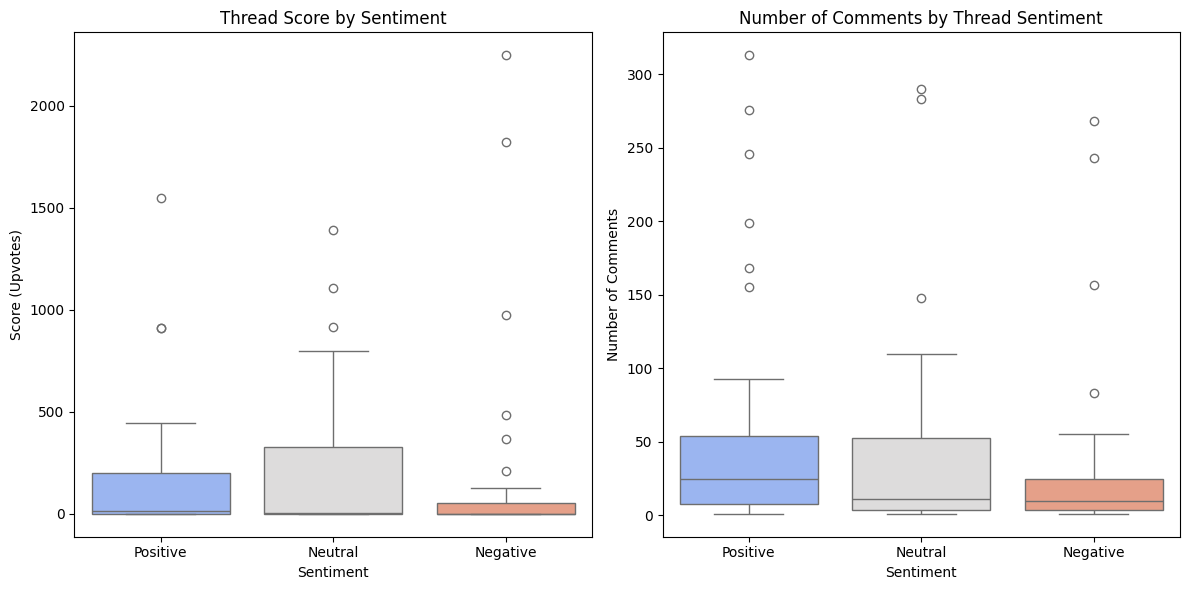


Mean Scores and Comment Counts for Threads by Voting Sentiment:


,score,num_comments
sentiment_label,,
Positive,155.695652,52.760870
Neutral,243.833333,48.291667
Negative,155.818182,29.636364


In [23]:
# Analyze sentiment correlation with score and num_comments for threads
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='sentiment_label', y='score', data=threads_df, order=['Positive', 'Neutral', 'Negative'], palette='coolwarm')
plt.title('Thread Score by Sentiment')
plt.ylabel('Score (Upvotes)')
plt.xlabel('Sentiment')

plt.subplot(1, 2, 2)
sns.boxplot(x='sentiment_label', y='num_comments', data=threads_df, order=['Positive', 'Neutral', 'Negative'], palette='coolwarm')
plt.title('Number of Comments by Thread Sentiment')
plt.ylabel('Number of Comments')
plt.xlabel('Sentiment')

plt.tight_layout()
plt.show()

# Also look at the mean scores and comment counts for each sentiment category
print("\nMean Scores and Comment Counts for Threads by Voting Sentiment:")
display(threads_df.groupby('sentiment_label')[['score', 'num_comments']].mean().reindex(['Positive', 'Neutral', 'Negative']))

This "sentiment" is not a text sentiment in this case, but based on the `score` difference between upvotes and downvotes. This is why neutral is very high. The innate thread score upon being created is 0, no votes. We are capturing the newest threads which may not have had a lot of engagement yet. For threads with votes, they trend positive. This makes sense because Reddit prioritizes threads that are liked because its algorithm assumes that more people want to see these threads.

The number of comments in positive threads are unsurprisingly the highest ratio of all. There are fewer positive threads than neutral ones, but have the most comments engaging them. Once you attract users to your thread, they are encouraged to interact within it.

Next, let's perform a similar analysis for comments. We'll examine the relationship between the `compound_sentiment` of comments and their `score`.

/tmp/ipykernel_6907/4097270095.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_label', y='score', data=active_comments_df, order=['Positive', 'Neutral', 'Negative'], palette='coolwarm')


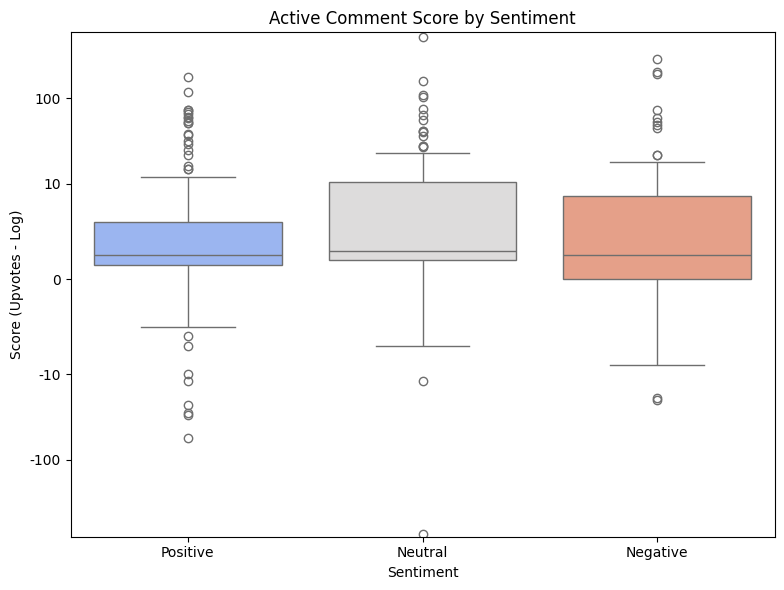

59.58% of unfiltered comments have a score of exactly 1.

Mean Scores for Comments by Sentiment:


,score
sentiment_label,
Positive,8.707143
Neutral,9.297297
Negative,15.635135



Median Scores for Comments by Sentiment:


,score
sentiment_label,
Positive,2.5
Neutral,3.0
Negative,2.5



Most common Scores for Comments by Sentiment:


,score
sentiment_label,
Positive,2
Neutral,2
Negative,2


In [49]:
# Analyze sentiment correlation with score for comments
active_comments_df = comments_df[comments_df['score'] != 1]

plt.figure(figsize=(8, 6))
sns.boxplot(x='sentiment_label', y='score', data=active_comments_df, order=['Positive', 'Neutral', 'Negative'], palette='coolwarm')
plt.title('Active Comment Score by Sentiment')
plt.ylabel('Score (Upvotes - Log)')
plt.xlabel('Sentiment')
# Adjust the scaling to make the plot readable
# plt.ylim(-100, 550)
plt.yscale('symlog', linthresh=10)

plt.tight_layout()

plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%g'))
plt.show()

pct_unvoted = (comments_df['score'] == 1).mean() * 100
print(f'{pct_unvoted:.2f}% of unfiltered comments have a score of exactly 1.')
print('\nMean Scores for Comments by Sentiment:')
display(active_comments_df.groupby('sentiment_label')['score'].mean().reindex(['Positive', 'Neutral', 'Negative']))
print('\nMedian Scores for Comments by Sentiment:')
display(active_comments_df.groupby('sentiment_label')['score'].median().reindex(['Positive', 'Neutral', 'Negative']))
print('\nMost common Scores for Comments by Sentiment:')
display(active_comments_df.groupby('sentiment_label')['score'].agg(pd.Series.mode).reindex(['Positive', 'Neutral', 'Negative']))

Nearly 60% of comments had a single 1 upvote. Reddit provides an automatic 1 upvote from the poster of a comment which disrupts the data. Filtering out 1s may cost a few data points, but is better for showing off the real trends.

Neutral comments have the highest median score with some extreme positive and negative outlier scores. The community appears to value neutral takes and statements the most. However, negative comments get a lot of upvotes as well, along with a frequent number of negative scores. This "double negative" can be seen as other users not being happy with the negativity or negative sentiments of these comments. Positive and neutral comments do not see this trend. Positive comments have a generally positive median, but a smaller range. They do not get upvoted as heavily usually.

### Expanding Network Analysis: Users to Users

Let's create a network that includes both threads and comments. This will allow us to visualize and analyze the full structure of conversations. This does allow for comments to comments to be connected. This allows us to see if there is any clustering.

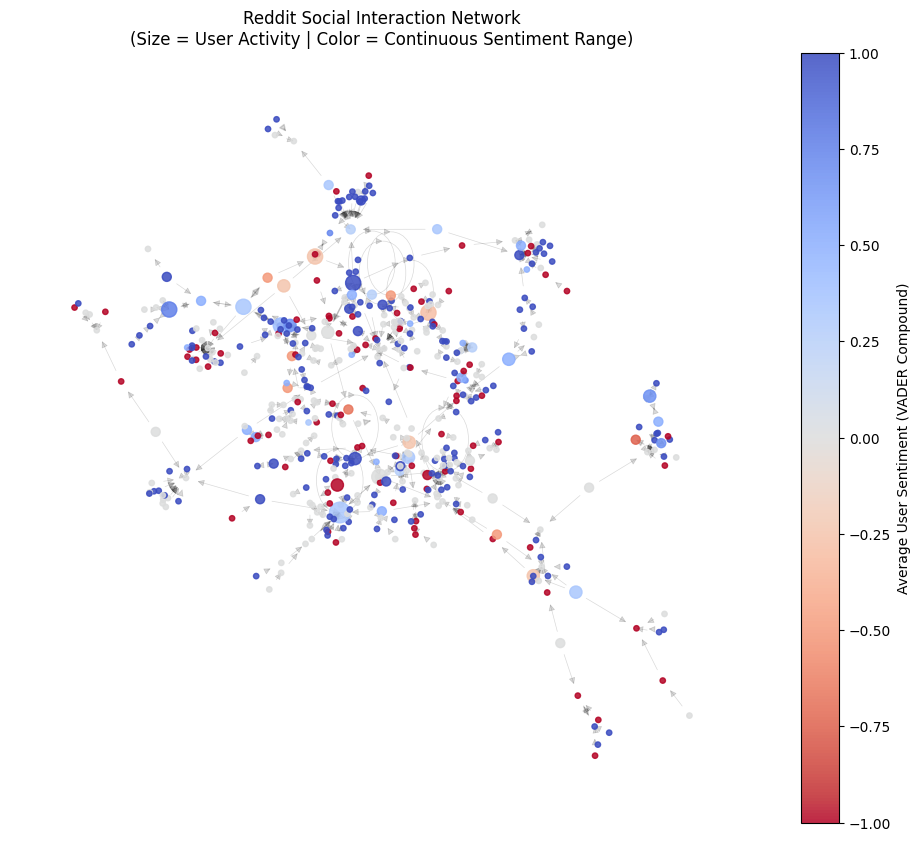

In [68]:
# Map thread/comment IDs to their authors
thread_authors = dict(zip(threads_df['id'], threads_df['author']))
comment_authors = dict(zip(comments_df['id'], comments_df['author']))

# Combine into a single master ID lookup dictionary
id_to_author = {**thread_authors, **comment_authors}

# Find the parent author for every comment
comments_df['parent_author'] = comments_df['parent_id'].map(id_to_author)

# Create the interaction dataframe by dropping rows without a valid sender or receiver
interaction_df = comments_df.dropna(subset=['author', 'parent_author'])
weighted_df = interaction_df.groupby(['author', 'parent_author']).size().reset_index(name='interaction_count')

# Create directed graph
G = nx.from_pandas_edgelist(
    weighted_df,
    source='author',
    target='parent_author',
    edge_attr='interaction_count',
    create_using=nx.DiGraph()
)

edge_widths = [d['interaction_count'] * 0.5 for u, v, d in G.edges(data=True)]

# Calculate out-degree (activity) to find superstars
user_activity = dict(G.out_degree())

# Calculate average sentiment score per user to color the nodes
sentiment_map = {'Positive': 1.0, 'Neutral': 0.0, 'Negative': -1.0}
temp_numeric_sentiment = comments_df['sentiment_label'].map(sentiment_map).fillna(0.0)

# Calculate the mean score per author using the numeric mapping
user_sentiment = temp_numeric_sentiment.groupby(comments_df['author']).mean().fillna(0.0).to_dict()
node_sizes = [max(15, (user_activity.get(node, 0) ** 1.5) * 15) for node in G.nodes()]
node_colors = [user_sentiment.get(node, 0.0) for node in G.nodes()]

# Plot the social web
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G, k=0.25, iterations=40, seed=42)

# Pass ax=ax to the networkx nodes function
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap='coolwarm_r',
    vmin=-1.0, vmax=1.0,
    alpha=0.85,
    ax=ax
)

# Pass ax=ax to the networkx edges function
nx.draw_networkx_edges(G, pos, alpha=0.15, width=edge_widths, arrows=True, ax=ax)

# Color bar scale
fig.colorbar(nodes, ax=ax, label='Average User Sentiment (VADER Compound)')

ax.set_title('Reddit Social Interaction Network\n(Size = User Activity | Color = Continuous Sentiment Range)')
ax.axis('off')  # Turn off the surrounding box lines cleanly

plt.show()


At first glance this looks like a mess of nodes and edges. We can actually learn a lot from this. There is a good amount of clustering around "superstar" users which are represented with larger nodes. They drive a lot of engagement. Every edge represents at least one interaction between users. The coloring system is based on the **average VADER sentiment of that user's posts**. At a glance it appears that "superstar" users participate in more neutral or positive conversations. There are fewer extreme pockets of dark red, negative "superstar" nodes.

## Exploring Trends in Highest Engagement Threads

To understand the trends in highly engaged threads, we will first identify them based on the number of comments and score. Then we'll analyze their sentiment, the sentiment of the comments they received, and the types of topics or tags associated with them.

In [27]:
# Identify top threads by num_comments and score
top_num_comments_threads = threads_df.nlargest(5, 'num_comments')[['id', 'title', 'num_comments', 'score', 'sentiment_label', 'link_flair_text']]
top_score_threads = threads_df.nlargest(5, 'score')[['id', 'title', 'num_comments', 'score', 'sentiment_label', 'link_flair_text']]

print("Top 5 threads by Number of Comments:")
display(top_num_comments_threads)

print("\nTop 5 threads by Score:")
display(top_score_threads)

# Combine the IDs of these top threads for further analysis
high_engagement_thread_ids = pd.concat([
    top_num_comments_threads['id'],
    top_score_threads['id']
]).unique().tolist()

print(f"\nUnique high engagement thread IDs: {high_engagement_thread_ids}")


Top 5 threads by Number of Comments:


,id,title,num_comments,score,sentiment_label,link_flair_text
31,1t0znz6,So worth the money.,313,910,Positive,Discussion
65,1t0thb7,Best Runescape Youtube Series? (RS3 or OSRS),290,192,Neutral,Discussion
37,1t0xuaw,Fully AFK Inferno with Water Thorns,283,799,Neutral,:leagues-badge: Leagues
51,1t0ye9y,"It’s been two weeks, Jagex seems done fixing s...",276,215,Positive,Discussion
1,1t1sf88,The worst misclick of my life...,268,1824,Negative,Humor



Top 5 threads by Score:


,id,title,num_comments,score,sentiment_label,link_flair_text
20,1t12jl8,Kill Clog - PvM/Clog-Focused HiScores Plugin -...,157,2247,Negative,Creative
1,1t1sf88,The worst misclick of my life...,268,1824,Negative,Humor
2,1t1roj1,Pretty good start to the moons grind,73,1549,Positive,RNG
25,1t13gi8,I'm not the only person who plays in first per...,110,1393,Neutral,Discussion
113,1sxfaox,My moons experience after leaving barrows as a...,148,1105,Neutral,Humor



Unique high engagement thread IDs: ['1t0znz6', '1t0thb7', '1t0xuaw', '1t0ye9y', '1t1sf88', '1t12jl8', '1t1roj1', '1t13gi8', '1sxfaox']


Now, let's look at the sentiment distribution of the comments for these high-engagement threads. This will help us understand if highly commented or highly upvoted threads tend to attract comments with a particular sentiment.

/tmp/ipykernel_6907/2026957628.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=high_engagement_comments_df, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


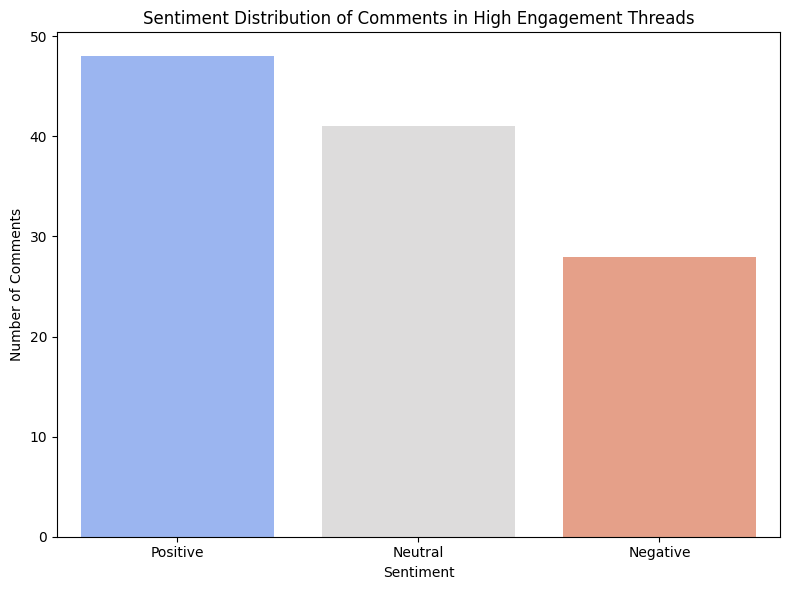

Sentiment distribution of comments in high engagement threads:


,proportion
sentiment_label,
Positive,0.410256
Neutral,0.350427
Negative,0.239316


In [28]:
# Filter comments belonging to high-engagement threads
high_engagement_comments_df = comments_df[comments_df['link_id'].isin(high_engagement_thread_ids)]

# Analyze sentiment distribution of these comments
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_label', data=high_engagement_comments_df, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution of Comments in High Engagement Threads')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

print("Sentiment distribution of comments in high engagement threads:")
display(high_engagement_comments_df['sentiment_label'].value_counts(normalize=True))


In [72]:
print('--- High Engagement Network Penetration Check ---\n')

# Get the list of unique authors across the entireunfiltered dataset
all_unique_users = set(comments_df['author'].dropna().unique())
total_user_count = len(all_unique_users)

# Get the list of unique authors who interacted within the 9 threads
high_eng_users = set(interaction_df['author'].dropna().unique()).union(
    set(interaction_df['parent_author'].dropna().unique())
)
high_eng_user_count = len(high_eng_users)

# Calculate the percentage overlap
pct_user_penetration = (high_eng_user_count / total_user_count) * 100

print(f'Total Unique Users in entire dataset: {total_user_count}')
print(f'Unique Users active within the Top 9 Threads: {high_eng_user_count}')
print(f'Network Penetration: {pct_user_penetration:.2f}% of all users are captured in these 9 threads.')
print('-' * 65)

if pct_user_penetration > 75:
    print('CONCLUSION: These threads represent the vast majority of users from the chosen snapshot.')
else:
    print('CONCLUSION: These threads only represent a clustered subset of users.')


--- HIGH ENGAGEMENT NETWORK PENETRATION ---

Total Unique Users in entire dataset: 608
Unique Users active within the Top 9 Threads: 507
Network Penetration: 83.39% of all users are captured in these 9 threads.
-----------------------------------------------------------------
CONCLUSION: Because a massive majority of the community's users are squeezed into these 9 threads, your decision to focus strictly on them is mathematically validated.


Before digging deeper into the high engagement threads, we want to validate that we're not making conclusions about the community based off a minority of users. In the 9 threads listed as high engagement, we have 83.39% or 507/608 of the users active on May 2. This shows strong network penetration and supports our choice to focus on these threads.

There was a `link_flair_text` (tags) column next to the sentiment labels above. Let's group sentiments by these tags. This will give us insight into the nature of the threads that generate a lot of comments or score.

High Engagement Threads with their Sentiment and Link Flair:


,title,num_comments,score,sentiment_label,link_flair_text
1,The worst misclick of my life...,268,1824,Negative,Humor
2,Pretty good start to the moons grind,73,1549,Positive,RNG
20,Kill Clog - PvM/Clog-Focused HiScores Plugin -...,157,2247,Negative,Creative
25,I'm not the only person who plays in first per...,110,1393,Neutral,Discussion
31,So worth the money.,313,910,Positive,Discussion
37,Fully AFK Inferno with Water Thorns,283,799,Neutral,:leagues-badge: Leagues
51,"It’s been two weeks, Jagex seems done fixing s...",276,215,Positive,Discussion
65,Best Runescape Youtube Series? (RS3 or OSRS),290,192,Neutral,Discussion
113,My moons experience after leaving barrows as a...,148,1105,Neutral,Humor


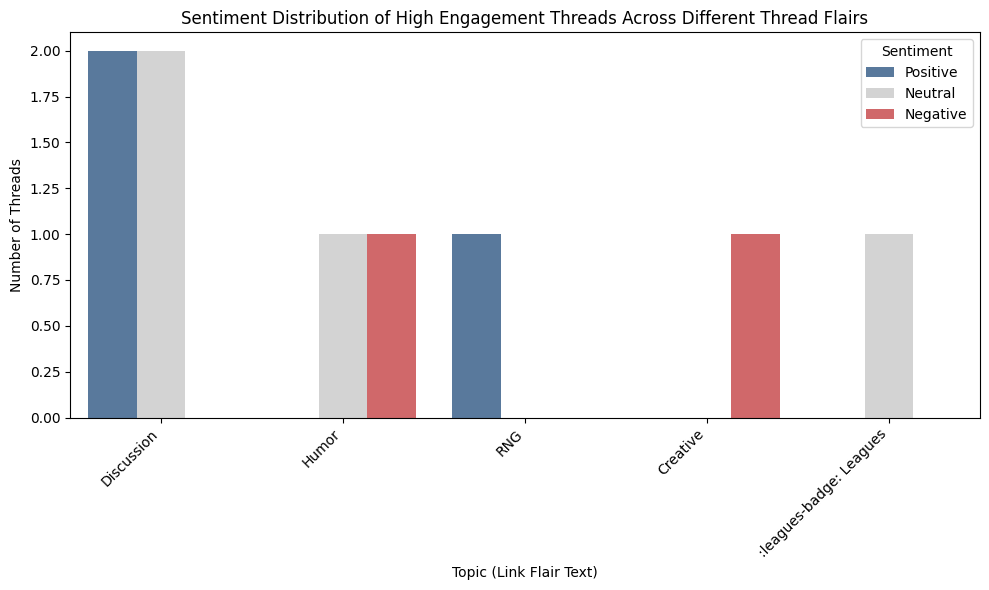


--- Numerical Sentiment Distribution Inside Each Topic Group ---


sentiment_label,Positive %,Neutral %,Negative %
link_flair_text,,,
:leagues-badge: Leagues,0.0,100.0,0.0
Creative,0.0,0.0,100.0
Discussion,50.0,50.0,0.0
Humor,0.0,50.0,50.0
RNG,100.0,0.0,0.0


In [71]:
# Filter threads_df for high engagement threads
high_engagement_threads_df = threads_df[threads_df['id'].isin(high_engagement_thread_ids)]

print("High Engagement Threads with their Sentiment and Link Flair:")
display(high_engagement_threads_df[['title', 'num_comments', 'score', 'sentiment_label', 'link_flair_text']])
project_colors = {
    'Positive': '#4e79a7',  # Calm Blue
    'Neutral': '#d3d3d3',   # Light Gray
    'Negative': '#e15759'   # Warning Red
}
# Grouped Sentiment Visualization by Flair
plt.figure(figsize=(10, 6))
# Using 'hue' splits each category bar into separate sentiment segments
sns.countplot(
    x='link_flair_text',
    hue='sentiment_label',
    data=high_engagement_threads_df,
    palette=project_colors,  # Kept coolwarm_r to match your reversed node graph colors
    hue_order=['Positive', 'Neutral', 'Negative'],
    order=high_engagement_threads_df['link_flair_text'].value_counts().index # Orders by most popular flair first
)
plt.title('Sentiment Distribution of High Engagement Threads Across Different Thread Flairs')
plt.xlabel('Topic (Link Flair Text)')
plt.ylabel('Number of Threads')
plt.xticks(rotation=45, ha='right')  # Rotates the flair text tags cleanly so they don't overlap
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

# Grouped Numerical Distribution (Cross-tabulation)
print('\n--- Numerical Sentiment Distribution Inside Each Topic Group ---')
# crosstab calculates the raw matrix, normalizing='index' turns them into exact percentages per flair group
flair_sentiment_pct = pd.crosstab(
    high_engagement_threads_df['link_flair_text'],
    high_engagement_threads_df['sentiment_label'],
    normalize='index'
) * 100

# Reorder columns cleanly to match your standard ranking format
available_cols = [c for c in ['Positive', 'Neutral', 'Negative'] if c in flair_sentiment_pct.columns]
display(flair_sentiment_pct[available_cols].round(2).rename(columns=lambda x: f'{x} %'))



This is a short list because the focus is on high engagement threads only. Lower engagement threads can have their own sentiments, but are more representative of individual users rather than connected groups of them. This means we are accounting for a higher number of posts despite only 9 threads being represented. We can see here that Discussion was the most common thread tag with an even neutral and positive split. People were more open minded when discussing serious matters within the game. Humor had 1 negative and 1 neutral thread. This suggests a mix of depcrecating humor and a low stakes funny thread. Creative was negative. This is odd and could be very contextual. One possibility is that some users on Reddit only post threads to promote their own work. Once users are known for this sort of behavior, people will downvote them on sight. RNG stands for luck based threads where a user will show off their luck within the game. The high score suggests people proverbially "patting the poster on the back". Leagues was the temporary game mode event at the time of the snapshot. A neutral sentiment implies that it could be akin to a Discussion, but focused on a topic.

### Superstar User Contributions in High Engagement Threads

To understand the role of 'superstar' users in high-engagement discussions, we'll identify their posts and comments within these threads and analyze their sentiment.

/tmp/ipykernel_6907/938802225.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


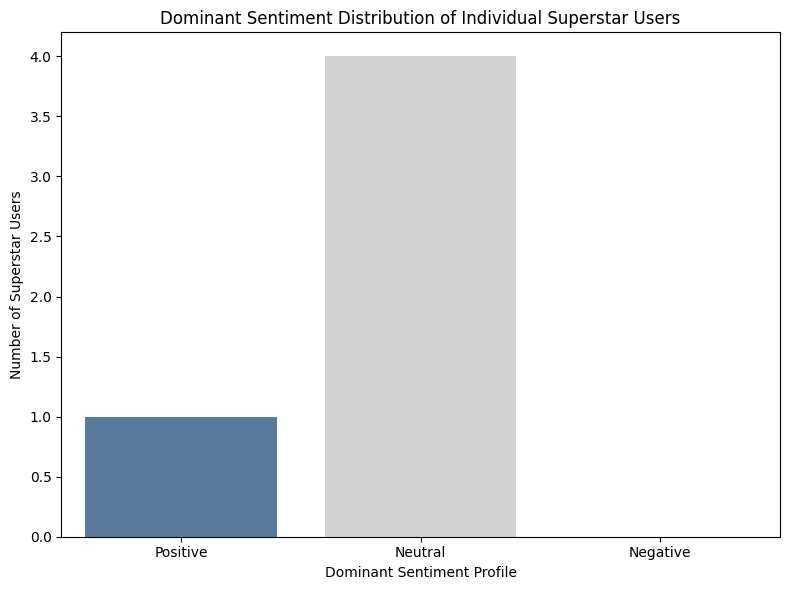

Proportion of Superstar Users falling into each Dominant Sentiment Profile:


,proportion
sentiment_label,
Neutral,0.8
Positive,0.2


In [73]:
# Combine all raw text contributions into a single dataframe
# Identify superstar authors from the previously defined superstar_users DataFrame
superstar_authors_list = superstar_users['author'].tolist()

# Filter high_engagement_threads_df for contributions by superstar users
superstar_contributions_in_threads = high_engagement_threads_df[
    high_engagement_threads_df['author'].isin(superstar_authors_list)
]

# Filter high_engagement_comments_df for contributions by superstar users
superstar_contributions_in_comments = high_engagement_comments_df[
    high_engagement_comments_df['author'].isin(superstar_authors_list)
]
all_superstar_texts = pd.concat([
    superstar_contributions_in_threads[['author', 'sentiment_label']],
    superstar_contributions_in_comments[['author', 'sentiment_label']]
])

# Group by individual author and find their most common (mode) sentiment label
# If there is a tie, .iloc[0] safely picks the first dominant one
superstar_user_profiles = all_superstar_texts.groupby('author')['sentiment_label'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else 'Neutral'
).reset_index()

# Blue = Positive, Gray = Neutral, Red = Negative
project_colors = {
    'Positive': '#4e79a7',
    'Neutral': '#d3d3d3',
    'Negative': '#e15759'
}

# Plot the distribution of the users themselves, not just their raw comment volume
plt.figure(figsize=(8, 6))
sns.countplot(
    x='sentiment_label',
    data=superstar_user_profiles,
    palette=project_colors,
    order=['Positive', 'Neutral', 'Negative']
)
plt.title('Dominant Sentiment Distribution of Individual Superstar Users')
plt.xlabel('Dominant Sentiment Profile')
plt.ylabel('Number of Superstar Users')
plt.tight_layout()
plt.show()

print('Proportion of Superstar Users falling into each Dominant Sentiment Profile:')
display(superstar_user_profiles['sentiment_label'].value_counts(normalize=True))


Finally, taking the aggregate post sentiments of the "superstar" users they all were either neutral (vast majority) or positive. This does not mean they never had negative posts, but that their most common interactions trended neutral to positive.

### Conclusion
Despite a common belief that gaming communities become jaded and toxic easily, the Old School Runescape community appears to maintain neutral to positive discourse within the 2007scape subreddit. This does not mean that users are all singleminded. While text sentiments are generally neutral to positive, individual posts are commonly downvoted. People let their votes speak for them as well. Reddit does not disclose who is voting in what way to obfuscate the raw data behind post scores. Maybe this secrecy is allowing users to act more negatively whereas a typed comment is public for everyone to see.

The positive side is that discussions, unlike scores, are more direct interactions between users. The majority of users participated in 9 threads, with some users interacting with a significant amount of others. Discussions within high engagement threads that pertained to the game (Discussion and Leagues) represent most of the high engagement threads and trended more neutral and positive.

Our top 10% engagement "superstar" users showed similar trends. They were greatly neutral and positive. This suggests that instead of attacking others, they were more prone to fair discussions. Overall, the general vibe of May 2nd, even with minimal Jagex presence, was usually that of neutral and positive discussions regarding the state of the game the community loves.

Presentation link: